# Part 4: More advanced networks

__Before starting, we recommend you enable GPU acceleration if you're running on Colab.__

In [ ]:
# Execute this code block to install dependencies
try:
    import torchbearer
except:
    !pip install torchbearer
    import torchbearer

Recent network models, such as the deep residual network (ResNet) and GoogLeNet architectures, do not follow a straight path from input to output. Instead, these models incorporate branches and merges to create a computation graph. Branching and merging is easy to implement in PyTorch as shown in the following code snippet:

In [ ]:
import torch
import torch.nn.functional as F
from torch import nn

class BranchModel(nn.Module):
    def __init__(self):
        super(BranchModel, self).__init__()
        self.left  = nn.Conv2d(1, 16, (1, 1), padding=0)
        self.right = nn.Conv2d(1, 16, (5, 5), padding=2)
        self.fc1 = nn.Linear(16*14*14, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        out_l = self.left(x)
        out_l = F.relu(out_l)

        out_r = self.right(x)
        out_r = F.relu(out_r)

        out = out_l + out_r

        out = F.max_pool2d(out, (2,2))
        out = F.dropout(out, 0.2)
        out = out.view(out.shape[0], -1)
        out = self.fc1(out)
        out = F.relu(out)
        out = self.fc2(out)

        return out

This defines a variant of our initial simple CNN model in which the input is split into two paths and then merged again; the left hand path consists of a 1x1 convolution layer, whilst the right-hand path has a 5x5 convolutional layer. The 1x1 convolutions will have the effect of increasing the number of bands in the input from 1 to 16 (with each band a (potentially different) scalar multiple of the input). Padding is used to ensure the feature maps have the same shape on the left and right branches. In this case the left and right branches are merged by summing them together (element-wise, layer by layer).

__Use the code block below to train and evaluate the above model.__

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()

## Going further

None of the network topology we have experimented with thus far are optimised. Nor are they reproductions of network topologies from recent papers.

__There is a lot of opportunity for you to tune and improve upon these models. What is the best error rate score you can achieve?__


Using device: cuda
Epoch 001: train_loss=61.8681, val_loss=50.3214
Epoch 002: train_loss=48.6456, val_loss=36.3346
Epoch 003: train_loss=30.2960, val_loss=29.7040
Epoch 004: train_loss=22.4387, val_loss=27.3148
Epoch 005: train_loss=20.6276, val_loss=25.7472
Epoch 006: train_loss=19.0322, val_loss=23.8591
Epoch 007: train_loss=17.8579, val_loss=23.1955
Epoch 008: train_loss=17.5612, val_loss=22.0673
Epoch 009: train_loss=15.8919, val_loss=22.7727
Epoch 010: train_loss=14.8302, val_loss=21.4421
Epoch 011: train_loss=14.3228, val_loss=20.7658
Epoch 012: train_loss=13.2199, val_loss=21.5832
Epoch 013: train_loss=12.3189, val_loss=20.7805
Epoch 014: train_loss=11.7722, val_loss=19.6345
Epoch 015: train_loss=10.7521, val_loss=18.7333
Epoch 016: train_loss=10.1153, val_loss=19.0381
Epoch 017: train_loss=9.4338, val_loss=18.0004
Epoch 018: train_loss=8.9928, val_loss=17.5384
Epoch 019: train_loss=8.4722, val_loss=19.9407
Epoch 020: train_loss=8.0211, val_loss=19.9408
Epoch 021: train_loss=8.1

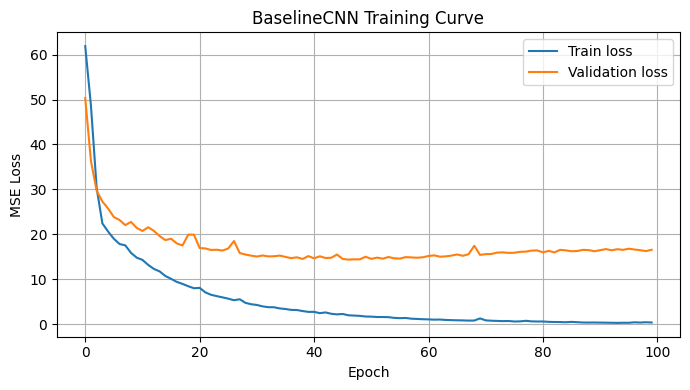

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt


# -------------------------
# 1. Device setup
# -------------------------
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)


# -------------------------
# 2. Dataset from the lab sheet
# -------------------------
class MyDataset(Dataset):
    def __init__(self, size=5000, dim=40, random_offset=0):
        super(MyDataset, self).__init__()
        self.size = size
        self.dim = dim
        self.random_offset = random_offset

    def __getitem__(self, index):
        if index >= len(self):
            raise IndexError("{} index out of range".format(self.__class__.__name__))

        rng_state = torch.get_rng_state()
        torch.manual_seed(index + self.random_offset)

        while True:
            img = torch.zeros(self.dim, self.dim)

            dx = torch.randint(-10, 10, (1,), dtype=torch.float)
            dy = torch.randint(-10, 10, (1,), dtype=torch.float)
            c = torch.randint(-20, 20, (1,), dtype=torch.float)

            # Avoid division by zero if dx happens to be 0
            if dx.item() == 0:
                continue

            params = torch.cat((dy / dx, c))

            xy = torch.randint(0, img.shape[1], (20, 2), dtype=torch.float)
            xy[:, 1] = xy[:, 0] * params[0] + params[1]
            xy.round_()

            xy = xy[xy[:, 1] > 0]
            xy = xy[xy[:, 1] < self.dim]
            xy = xy[xy[:, 0] < self.dim]

            for i in range(xy.shape[0]):
                x, y = xy[i][0], self.dim - xy[i][1]
                img[int(y), int(x)] = 1

            if img.sum() > 2:
                break

        torch.set_rng_state(rng_state)

        # img shape: 1 × 40 × 40
        # params shape: 2, containing [slope, intercept]
        return img.unsqueeze(0), params

    def __len__(self):
        return self.size


# -------------------------
# 3. Create train, validation and test data
# -------------------------
train_data = MyDataset(size=5000)
val_data = MyDataset(size=500, random_offset=33333)
test_data = MyDataset(size=500, random_offset=99999)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)


# -------------------------
# 4. Baseline CNN for Task 1
# -------------------------
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Input: batch × 1 × 40 × 40
        # Output: batch × 48 × 40 × 40
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=48,
            kernel_size=3,
            stride=1,
            padding=1
        )

        # Flattened size after conv1:
        # 48 × 40 × 40 = 76800
        self.fc1 = nn.Linear(48 * 40 * 40, 128)

        # Output: [slope, intercept]
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = x.view(x.shape[0], -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


# -------------------------
# 5. Training function
# -------------------------
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()

    total_loss = 0.0
    total_items = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        pred = model(x)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_items += x.size(0)

    return total_loss / total_items


# -------------------------
# 6. Evaluation function
# -------------------------
def evaluate(model, loader, loss_fn, device):
    model.eval()

    total_loss = 0.0
    total_items = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            pred = model(x)
            loss = loss_fn(pred, y)

            total_loss += loss.item() * x.size(0)
            total_items += x.size(0)

    return total_loss / total_items


# -------------------------
# 7. Train BaselineCNN
# -------------------------
model = BaselineCNN().to(device)

# This is a regression task, so we use MSE loss
loss_fn = nn.MSELoss()

# Adam with default parameters, as required by the task
optimizer = torch.optim.Adam(model.parameters())

num_epochs = 100

history = {
    "train_loss": [],
    "val_loss": []
}

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
    val_loss = evaluate(model, val_loader, loss_fn, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(
        f"Epoch {epoch+1:03d}: "
        f"train_loss={train_loss:.4f}, "
        f"val_loss={val_loss:.4f}"
    )


# -------------------------
# 8. Final test loss
# -------------------------
test_loss = evaluate(model, test_loader, loss_fn, device)

print("\nFinal results for BaselineCNN:")
print(f"Final train loss: {history['train_loss'][-1]:.4f}")
print(f"Final val loss:   {history['val_loss'][-1]:.4f}")
print(f"Final test loss:  {test_loss:.4f}")


# -------------------------
# 9. Plot training and validation loss
# -------------------------
plt.figure(figsize=(7, 4))
plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("BaselineCNN Training Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("baseline_cnn_loss.png", dpi=200)
plt.show()

Using device: cuda
Epoch 001: train_loss=63.4054, val_loss=53.0634
Epoch 002: train_loss=56.9445, val_loss=48.2868
Epoch 003: train_loss=47.8354, val_loss=36.6344
Epoch 004: train_loss=35.2442, val_loss=28.2572
Epoch 005: train_loss=26.8126, val_loss=25.5145
Epoch 006: train_loss=25.2107, val_loss=24.1893
Epoch 007: train_loss=23.8740, val_loss=23.3744
Epoch 008: train_loss=23.4182, val_loss=23.0955
Epoch 009: train_loss=23.3341, val_loss=25.1526
Epoch 010: train_loss=22.9281, val_loss=22.6511
Epoch 011: train_loss=22.6240, val_loss=22.4721
Epoch 012: train_loss=22.4950, val_loss=22.1963
Epoch 013: train_loss=22.1087, val_loss=21.6833
Epoch 014: train_loss=21.6512, val_loss=22.4684
Epoch 015: train_loss=21.4465, val_loss=21.1238
Epoch 016: train_loss=21.2457, val_loss=21.6413
Epoch 017: train_loss=21.0693, val_loss=20.7470
Epoch 018: train_loss=21.0232, val_loss=20.9825
Epoch 019: train_loss=20.8073, val_loss=24.1607
Epoch 020: train_loss=21.6431, val_loss=21.5480
Epoch 021: train_loss

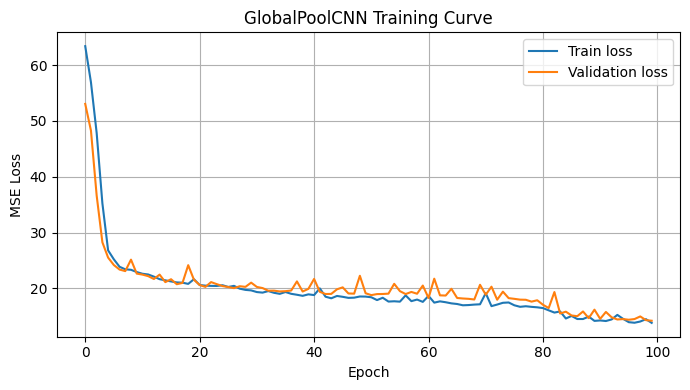

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt


# -------------------------
# 1. Device setup
# -------------------------
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)


# -------------------------
# 2. Dataset from the lab sheet
# -------------------------
class MyDataset(Dataset):
    def __init__(self, size=5000, dim=40, random_offset=0):
        super(MyDataset, self).__init__()
        self.size = size
        self.dim = dim
        self.random_offset = random_offset

    def __getitem__(self, index):
        if index >= len(self):
            raise IndexError("{} index out of range".format(self.__class__.__name__))

        rng_state = torch.get_rng_state()
        torch.manual_seed(index + self.random_offset)

        while True:
            img = torch.zeros(self.dim, self.dim)

            dx = torch.randint(-10, 10, (1,), dtype=torch.float)
            dy = torch.randint(-10, 10, (1,), dtype=torch.float)
            c = torch.randint(-20, 20, (1,), dtype=torch.float)

            # Avoid division by zero
            if dx.item() == 0:
                continue

            params = torch.cat((dy / dx, c))

            xy = torch.randint(0, img.shape[1], (20, 2), dtype=torch.float)
            xy[:, 1] = xy[:, 0] * params[0] + params[1]
            xy.round_()

            xy = xy[xy[:, 1] > 0]
            xy = xy[xy[:, 1] < self.dim]
            xy = xy[xy[:, 0] < self.dim]

            for i in range(xy.shape[0]):
                x, y = xy[i][0], self.dim - xy[i][1]
                img[int(y), int(x)] = 1

            if img.sum() > 2:
                break

        torch.set_rng_state(rng_state)

        # input shape: 1 × 40 × 40
        # target shape: 2, containing [slope, intercept]
        return img.unsqueeze(0), params

    def __len__(self):
        return self.size


# -------------------------
# 3. Create train, validation and test data
# -------------------------
train_data = MyDataset(size=5000)
val_data = MyDataset(size=500, random_offset=33333)
test_data = MyDataset(size=500, random_offset=99999)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)


# -------------------------
# 4. Task 2 model: CNN with Global Max Pooling
# -------------------------
class GlobalPoolCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Input: batch × 1 × 40 × 40
        # Output: batch × 48 × 40 × 40
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=48,
            kernel_size=3,
            stride=1,
            padding=1
        )

        # Output: batch × 48 × 40 × 40
        self.conv2 = nn.Conv2d(
            in_channels=48,
            out_channels=48,
            kernel_size=3,
            stride=1,
            padding=1
        )

        # Global max pooling:
        # batch × 48 × 40 × 40 -> batch × 48 × 1 × 1
        self.pool = nn.AdaptiveMaxPool2d((1, 1))

        # After flattening: batch × 48
        self.fc1 = nn.Linear(48, 128)

        # Output: slope and intercept
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.shape[0], -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


# -------------------------
# 5. Training function
# -------------------------
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()

    total_loss = 0.0
    total_items = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        pred = model(x)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_items += x.size(0)

    return total_loss / total_items


# -------------------------
# 6. Evaluation function
# -------------------------
def evaluate(model, loader, loss_fn, device):
    model.eval()

    total_loss = 0.0
    total_items = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            pred = model(x)
            loss = loss_fn(pred, y)

            total_loss += loss.item() * x.size(0)
            total_items += x.size(0)

    return total_loss / total_items


# -------------------------
# 7. Train GlobalPoolCNN
# -------------------------
model = GlobalPoolCNN().to(device)

# Regression task: predict [slope, intercept]
loss_fn = nn.MSELoss()

# Adam with default parameters
optimizer = torch.optim.Adam(model.parameters())

num_epochs = 100

history = {
    "train_loss": [],
    "val_loss": []
}

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
    val_loss = evaluate(model, val_loader, loss_fn, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(
        f"Epoch {epoch+1:03d}: "
        f"train_loss={train_loss:.4f}, "
        f"val_loss={val_loss:.4f}"
    )


# -------------------------
# 8. Final test loss
# -------------------------
test_loss = evaluate(model, test_loader, loss_fn, device)

print("\nFinal results for GlobalPoolCNN:")
print(f"Final train loss: {history['train_loss'][-1]:.4f}")
print(f"Final val loss:   {history['val_loss'][-1]:.4f}")
print(f"Final test loss:  {test_loss:.4f}")


# -------------------------
# 9. Plot training and validation loss
# -------------------------
plt.figure(figsize=(7, 4))
plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("GlobalPoolCNN Training Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("global_pool_cnn_loss.png", dpi=200)
plt.show()

Using device: cuda
Epoch 001: train_loss=63.7623, val_loss=52.0619
Epoch 002: train_loss=52.0216, val_loss=36.4537
Epoch 003: train_loss=27.9659, val_loss=16.9464
Epoch 004: train_loss=14.9230, val_loss=11.9427
Epoch 005: train_loss=11.3557, val_loss=11.2661
Epoch 006: train_loss=9.6245, val_loss=8.0855
Epoch 007: train_loss=7.9587, val_loss=6.5542
Epoch 008: train_loss=6.8702, val_loss=7.6644
Epoch 009: train_loss=6.6106, val_loss=5.7006
Epoch 010: train_loss=6.0722, val_loss=6.1366
Epoch 011: train_loss=5.6061, val_loss=5.6475
Epoch 012: train_loss=5.4765, val_loss=5.5087
Epoch 013: train_loss=5.3062, val_loss=5.5074
Epoch 014: train_loss=5.2312, val_loss=4.9113
Epoch 015: train_loss=4.9747, val_loss=4.8195
Epoch 016: train_loss=4.6861, val_loss=4.4814
Epoch 017: train_loss=4.5882, val_loss=4.4679
Epoch 018: train_loss=4.3917, val_loss=4.2112
Epoch 019: train_loss=4.3682, val_loss=4.1315
Epoch 020: train_loss=4.1789, val_loss=4.0019
Epoch 021: train_loss=4.0759, val_loss=3.9552
Epoch

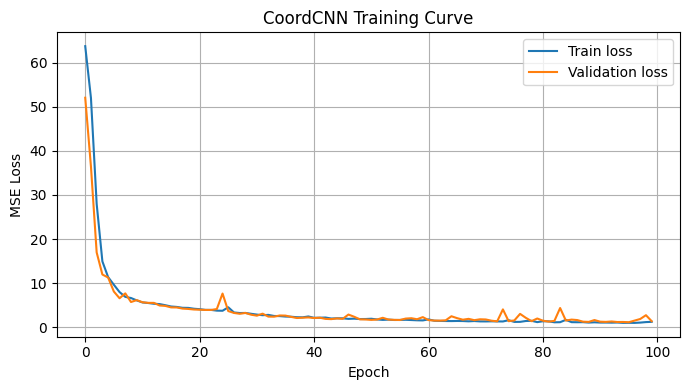

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt


# -------------------------
# 1. Device setup
# -------------------------
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)


# -------------------------
# 2. Dataset from the lab sheet
# -------------------------
class MyDataset(Dataset):
    def __init__(self, size=5000, dim=40, random_offset=0):
        super(MyDataset, self).__init__()
        self.size = size
        self.dim = dim
        self.random_offset = random_offset

    def __getitem__(self, index):
        if index >= len(self):
            raise IndexError("{} index out of range".format(self.__class__.__name__))

        rng_state = torch.get_rng_state()
        torch.manual_seed(index + self.random_offset)

        while True:
            img = torch.zeros(self.dim, self.dim)

            dx = torch.randint(-10, 10, (1,), dtype=torch.float)
            dy = torch.randint(-10, 10, (1,), dtype=torch.float)
            c = torch.randint(-20, 20, (1,), dtype=torch.float)

            # Avoid division by zero
            if dx.item() == 0:
                continue

            params = torch.cat((dy / dx, c))

            xy = torch.randint(0, img.shape[1], (20, 2), dtype=torch.float)
            xy[:, 1] = xy[:, 0] * params[0] + params[1]
            xy.round_()

            xy = xy[xy[:, 1] > 0]
            xy = xy[xy[:, 1] < self.dim]
            xy = xy[xy[:, 0] < self.dim]

            for i in range(xy.shape[0]):
                x, y = xy[i][0], self.dim - xy[i][1]
                img[int(y), int(x)] = 1

            if img.sum() > 2:
                break

        torch.set_rng_state(rng_state)

        return img.unsqueeze(0), params

    def __len__(self):
        return self.size


# -------------------------
# 3. Create train, validation and test data
# -------------------------
train_data = MyDataset(size=5000)
val_data = MyDataset(size=500, random_offset=33333)
test_data = MyDataset(size=500, random_offset=99999)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)


# -------------------------
# 4. Task 3 model: CoordCNN
# -------------------------
class CoordCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Input has 3 channels:
        # 1 image channel + 2 coordinate channels
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=48,
            kernel_size=3,
            stride=1,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            in_channels=48,
            out_channels=48,
            kernel_size=3,
            stride=1,
            padding=1
        )

        self.pool = nn.AdaptiveMaxPool2d((1, 1))

        self.fc1 = nn.Linear(48, 128)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        # Create coordinate channels
        idxx = torch.repeat_interleave(
            torch.arange(-20, 20, dtype=torch.float).unsqueeze(0) / 40.0,
            repeats=40,
            dim=0
        ).to(x.device)

        idxy = idxx.clone().t()

        idx = torch.stack([idxx, idxy]).unsqueeze(0)
        idx = torch.repeat_interleave(idx, repeats=x.shape[0], dim=0)

        # Concatenate original image and coordinate channels
        x = torch.cat([x, idx], dim=1)

        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.shape[0], -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x


# -------------------------
# 5. Training function
# -------------------------
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()

    total_loss = 0.0
    total_items = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        pred = model(x)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_items += x.size(0)

    return total_loss / total_items


# -------------------------
# 6. Evaluation function
# -------------------------
def evaluate(model, loader, loss_fn, device):
    model.eval()

    total_loss = 0.0
    total_items = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            pred = model(x)
            loss = loss_fn(pred, y)

            total_loss += loss.item() * x.size(0)
            total_items += x.size(0)

    return total_loss / total_items


# -------------------------
# 7. Train CoordCNN
# -------------------------
model = CoordCNN().to(device)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters())

num_epochs = 100

history = {
    "train_loss": [],
    "val_loss": []
}

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
    val_loss = evaluate(model, val_loader, loss_fn, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(
        f"Epoch {epoch+1:03d}: "
        f"train_loss={train_loss:.4f}, "
        f"val_loss={val_loss:.4f}"
    )


# -------------------------
# 8. Final test loss
# -------------------------
test_loss = evaluate(model, test_loader, loss_fn, device)

print("\nFinal results for CoordCNN:")
print(f"Final train loss: {history['train_loss'][-1]:.4f}")
print(f"Final val loss:   {history['val_loss'][-1]:.4f}")
print(f"Final test loss:  {test_loss:.4f}")


# -------------------------
# 9. Plot training and validation loss
# -------------------------
plt.figure(figsize=(7, 4))
plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("CoordCNN Training Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("coord_cnn_loss.png", dpi=200)
plt.show()